# 2000-2023 initial data analysis on team winning percentage

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from source.stats import *
from source.visualisation import *
from source.features import create_feature_df

## Read csv and Display Format

In [2]:
df = pd.read_csv("../Data/afl_stats.csv")
df.head()

,Game,Season,Date,Round,Home_Team,Home_Points,Away_Team,Away_Points,Winner,Home_Points_By,...,Home_Points_For_4,Away_Points_For_4,Home_Points_Against_4,Away_Points_Against_4,Home_Points_For_5,Away_Points_For_5,Home_Points_Against_5,Away_Points_Against_5,Home_Rank,Away_Rank
0,11728,2000,2000-03-08,R1,Richmond,94,Melbourne,92,Home,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,11729,2000,2000-03-09,R1,Essendon,156,Port Adelaide,62,Home,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,11730,2000,2000-03-10,R1,North Melbourne,111,West Coast,154,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
3,11731,2000,2000-03-11,R1,Adelaide,108,Footscray,131,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,11732,2000,2000-03-11,R1,Fremantle,107,Geelong,129,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0


## Run Analysis Functions

In [3]:
team_games = calculate_team_games(df)

team_wins = calculate_team_wins(df)

team_home_win_percentage = calculate_home_win_percentage(df)

team_away_win_percentage = calculate_away_win_percentage(df)

team_win_percentage = calculate_team_win_percentage(team_games, team_wins)

home_advantage = calculate_home_advantage(df)

team_points = calculate_team_avg_points(df, team_games)

team_avg_winning_margin = calculate_team_avg_winning_margin(df)

team_points_conceded = calculate_team_avg_points_conceded(df, team_games)

team_avg_pt_differential = calculate_team_avg_pt_differential(df)

In [4]:
feature_df = create_feature_df(df)

feature_df.to_csv("../data/processed/features.csv", index=False)

feature_df.head(20)

,Season,Home_Team,Away_Team,Home_Win_Percentage,Away_Win_Percentage,Home_Avg_Points_For,Away_Avg_Points_For,Home_Avg_Points_Conceded,Away_Avg_Points_Conceded,Home_Avg_Points_Differential,Away_Avg_Points_Differential,Home_Last5_Win_Percentage,Away_Last5_Win_Percentage,Home_Last5_Avg_Points_For,Away_Last5_Avg_Points_For,Home_Last5_Avg_Points_Conceded,Away_Last5_Avg_Points_Conceded,Home_Last5_Avg_Points_Differential,Away_Last5_Avg_Points_Differential,Winner
0,2000,Richmond,Melbourne,50.0,50.0,90.00,90.00,90.00,90.00,0.0,0.0,50.0,50.0,90.0,90.00,90.00,90.00,0.0,0.0,Home
1,2000,Essendon,Port Adelaide,50.0,50.0,93.00,93.00,93.00,93.00,0.0,0.0,50.0,50.0,90.0,93.00,93.00,93.00,0.0,0.0,Home
2,2000,North Melbourne,West Coast,50.0,50.0,101.00,101.00,101.00,101.00,0.0,0.0,50.0,50.0,90.0,101.00,101.00,101.00,0.0,0.0,Away
3,2000,Adelaide,Footscray,50.0,50.0,111.50,111.50,111.50,111.50,0.0,0.0,50.0,50.0,90.0,111.50,111.50,111.50,0.0,0.0,Away
4,2000,Fremantle,Geelong,50.0,50.0,113.50,113.50,113.50,113.50,0.0,0.0,50.0,50.0,90.0,113.50,113.50,113.50,0.0,0.0,Away
5,2000,St Kilda,Sydney,50.0,50.0,114.40,114.40,114.40,114.40,0.0,0.0,50.0,50.0,90.0,114.40,114.40,114.40,0.0,0.0,Away
6,2000,Carlton,Brisbane Lions,50.0,50.0,114.83,114.83,114.83,114.83,0.0,0.0,50.0,50.0,90.0,114.83,114.83,114.83,0.0,0.0,Home
7,2000,Hawthorn,Collingwood,50.0,50.0,117.29,117.29,117.29,117.29,0.0,0.0,50.0,50.0,90.0,117.29,117.29,117.29,0.0,0.0,Away
8,2000,Essendon,Richmond,100.0,50.0,156.00,94.00,62.00,92.00,94.0,2.0,100.0,100.0,156.0,94.00,62.00,92.00,94.0,2.0,Home
9,2000,Melbourne,North Melbourne,50.0,50.0,92.00,111.00,94.00,154.00,-2.0,-43.0,0.0,0.0,92.0,111.00,94.00,154.00,-2.0,-43.0,Home


## Plot home win percentage

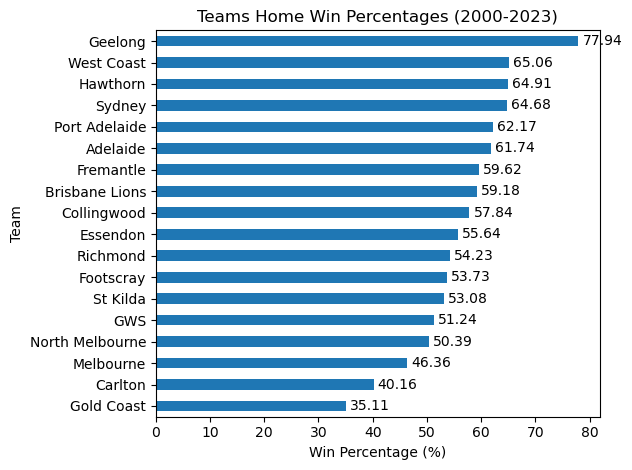

In [33]:
sorted_home_percentage = sort_dict(team_home_win_percentage)

plot_horizontal_bar(sorted_home_percentage, 
                    'Teams Home Win Percentages (2000-2023)',
                    'Win Percentage (%)',
                    'Team')

## Plot away win percentage

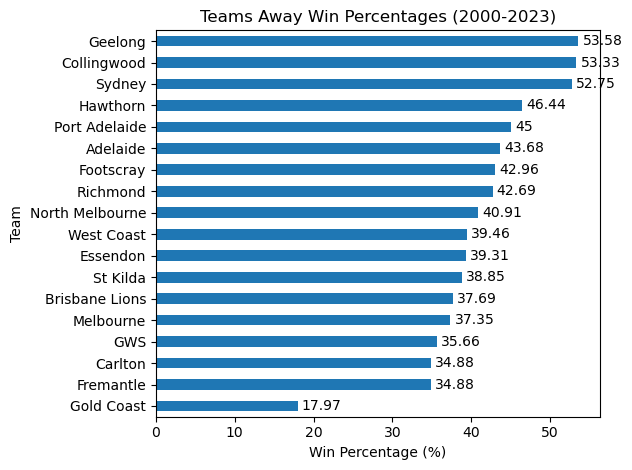

In [34]:
sorted_away_percentage = sort_dict(team_away_win_percentage)

plot_horizontal_bar(sorted_away_percentage,
                    'Teams Away Win Percentages (2000-2023)',
                    'Win Percentage (%)',
                    'Team')

## Display win percentage graph

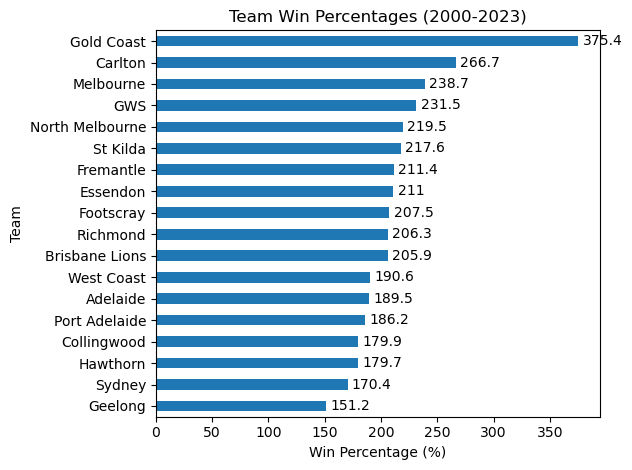

In [35]:
sorted_percentage = sort_dict(team_win_percentage)

plot_horizontal_bar(sorted_percentage,
                    'Team Win Percentages (2000-2023)',
                    'Win Percentage (%)',
                    'Team')

## Plot home advantage

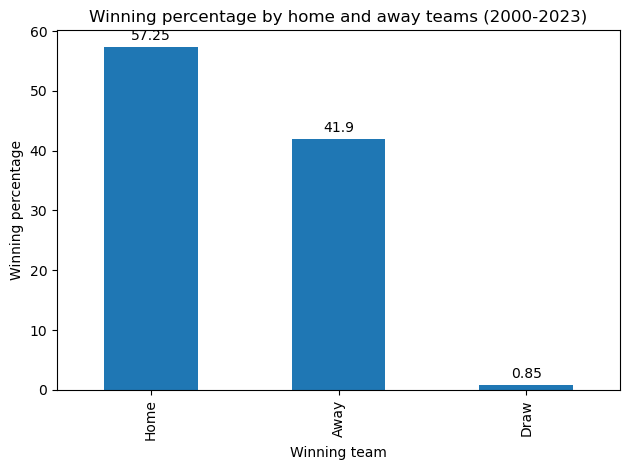

In [36]:
plot_bar(home_advantage,
         "Winning percentage by home and away teams (2000-2023)",
         "Winning team",
         "Winning percentage")

## Plot average points per game per team

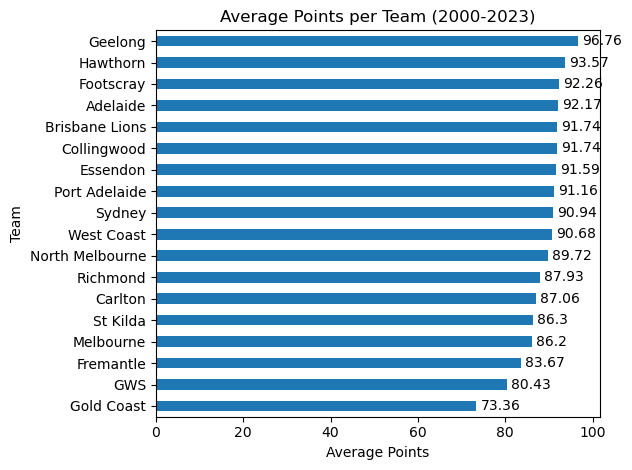

In [37]:
sorted_avg_points = sort_dict(team_points)

plot_horizontal_bar(sorted_avg_points,
                    'Average Points per Team (2000-2023)',
                    'Average Points',
                    'Team')

## Plot teams average winning margin

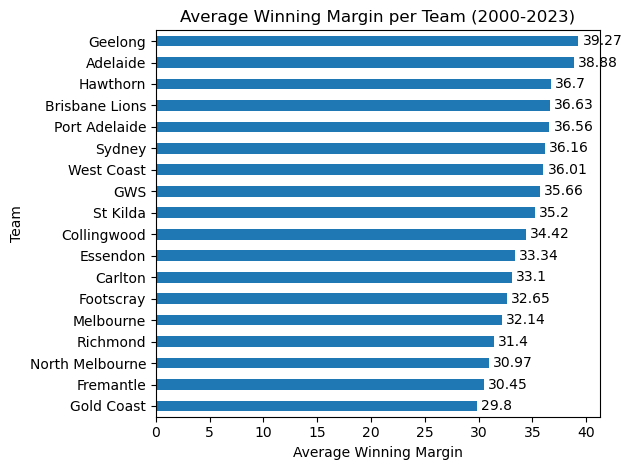

In [38]:
sorted_avg_winning_margin = sort_dict(team_avg_winning_margin)

plot_horizontal_bar(sorted_avg_winning_margin,
                    'Average Winning Margin per Team (2000-2023)',
                    'Average Winning Margin',
                    'Team')

## Plot average points conceded

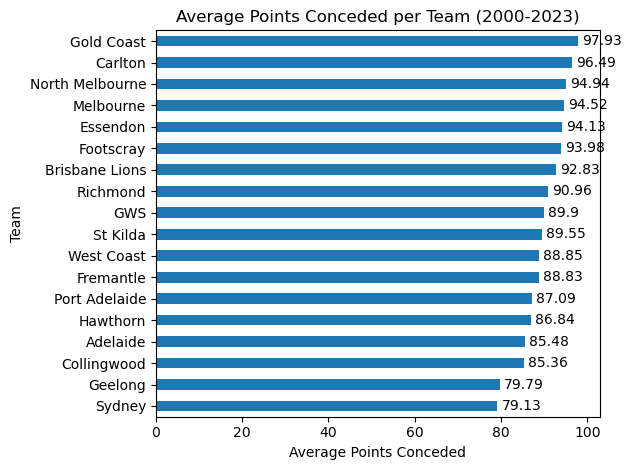

In [39]:
sorted_avg_points_conceded = sort_dict(team_points_conceded)

plot_horizontal_bar(sorted_avg_points_conceded,
                    'Average Points Conceded per Team (2000-2023)',
                    'Average Points Conceded',
                    'Team')

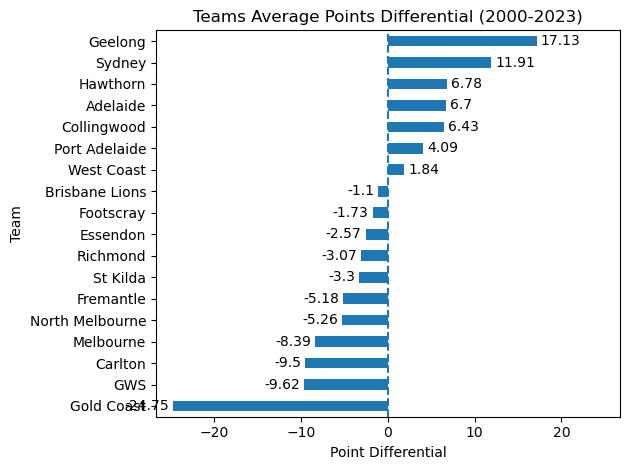

In [40]:
sorted_pt_differential = sort_dict(team_avg_pt_differential)

plot_horizontal_bar(sorted_pt_differential, 
                    'Teams Average Points Differential (2000-2023)',
                    'Point Differential',
                    'Team',
                    center_zero = True)